In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/student/student_exam_data_new.csv')

In [5]:
df.head(10)

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0
5,2.403951,49.757016,0
6,1.522753,94.655631,0
7,8.795585,89.352235,1
8,6.410035,96.987995,1
9,7.372653,83.543171,1


# Data Exploration

In [6]:
df.shape

(500, 3)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Study Hours          500 non-null    float64
 1   Previous Exam Score  500 non-null    float64
 2   Pass/Fail            500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


In [8]:
df.isna().any()

,0
Study Hours,False
Previous Exam Score,False
Pass/Fail,False


In [9]:
df.isnull().sum()

,0
Study Hours,0
Previous Exam Score,0
Pass/Fail,0


In [10]:
df.describe()

,Study Hours,Previous Exam Score,Pass/Fail
count,500.000000,500.000000,500.000000
mean,5.487055,68.917084,0.368000
std,2.688196,17.129607,0.482744
min,1.045554,40.277921,0.000000
25%,3.171517,53.745955,0.000000
50%,5.618474,68.309294,0.000000
75%,7.805124,83.580209,1.000000
max,9.936683,99.983060,1.000000


# Explanatory Data Analysis

In [11]:
df['Pass/Fail'].value_counts()

,count
Pass/Fail,
0,316
1,184


In [12]:
fig = px.pie(values = df['Pass/Fail'].value_counts(), names = df['Pass/Fail'].unique(),
             title = 'Students Performance as Percentage')
fig.update_traces(marker_colors = ['maroon', 'beige'], text = ['Fail', 'Pass'],
                  textinfo = 'text+percent', marker_line_color = 'seagreen',
                  marker_line_width = 1)
fig.update_layout(title = {'font_color' : 'orchid', 'x': 0.5, 'y' : 0.9,
                           'xanchor' : 'center', 'yanchor' : 'top'})
fig.show()

In [13]:
#Mean of previous exam score
score_mean = np.mean(df['Previous Exam Score'])
score_median = np.median(df['Previous Exam Score'])

print(f"Mean of previous exam score is:  {score_mean:.2f}")
print(f"Median of previous exam score is:  {score_median:.2f}")

Mean of previous exam score is:  68.92
Median of previous exam score is:  68.31


In [14]:
#Standard deviation is a measure of the amount of deviation in a set of values.
#Low standard deviation indicates that the values tend to be close to tne mean
#Larger standard deviation indicates
score_std = np.std(df['Previous Exam Score'])
print(f"Standard deviation of previous exam score is:  {score_std:.2f}")

Standard deviation of previous exam score is:  17.11


In [15]:
#Skewness measures the asymmetry of the distribution of a continuous variable
score_skew = stats.skew(df['Previous Exam Score'])
print(f"Skewness of previous exam score is:  {score_skew:.2f}")

Skewness of previous exam score is:  0.10


In [16]:
#Kurtosis describes how much area is in a distribution's tail relative to th normal distribution
score_kurto = stats.kurtosis(df['Previous Exam Score'])
print(f"Kurtosis of previous exam score is:  {score_kurto:.2f}")

Kurtosis of previous exam score is:  -1.19


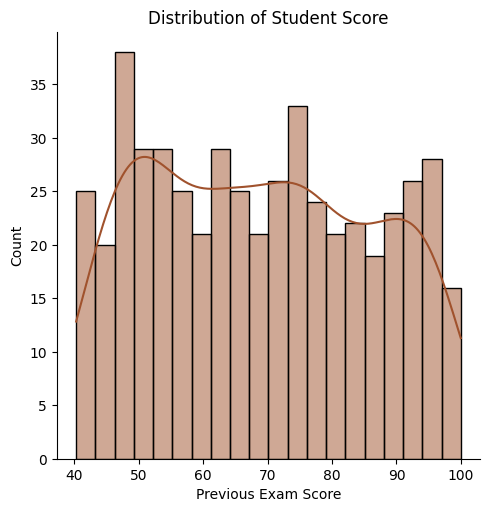

In [17]:
#Distribution curve of previous exam score
sns.displot(x = df['Previous Exam Score'],bins = 20, kde = 'normal', color = 'sienna')
plt.title('Distribution of Student Score')
plt.show()

The graph indicates that the variable is multimodal. The distribution curve is more flat that is the curve is platykurtic.

In [18]:
#Histogram representing the distribution of previous exam score
fig = px.histogram(df, x = 'Previous Exam Score', nbins = 20,
                   title = 'Distribution of Scores', text_auto = True)
fig.update_traces(marker_color = 'beige', marker_line_width = 1,
                  marker_line_color = 'lightslategray')
fig.update_layout(width = 800, height = 750)
fig.show()

The graph indicates that most of the students score ranges between 51% to 85%. There are no outliers in the marks of students. It indicates that average variation around the mean is large.

In [19]:
#Scatter plot of study hours vs score
fig = px.scatter(df, x = 'Study Hours', y = 'Previous Exam Score',
                title = 'Relation Between Study Hours and Scores', trendline = 'ols',
                trendline_color_override = 'darkslategray')
fig.update_traces(marker_color = 'coral', marker_symbol = 'star',
                 marker_size = 10, marker_line_color = 'sienna',
                 marker_line_width = 1.5)
fig.show()

The scatter plot indicates that there is no relation between number of study hours and marks obtained. This is also indicated by the trendline that there is no association between the varibles.

In [20]:
corr = df['Previous Exam Score'].corr(df['Study Hours'])
print(f'Correlation coefficient between exam score and study hours is: {corr:.2f}')

Correlation coefficient between exam score and study hours is: 0.01


In [21]:
#Box plot
fig = go.Figure()
fig.add_trace(go.Box(y = df['Previous Exam Score'], boxmean = True, name = 'Score',
                    marker_color = 'olive'))
fig.add_trace(go.Box(y = df['Study Hours'], boxmean = True, name = 'Study Hours',
                    marker_color = 'salmon'))
fig.update_layout(title = 'Detecting The Outliers', height = 750, width = 750)
fig.show()

The graph indicates the median and mean of previous exam score and study hours. The mean and median are approximately equal for previous exam score as well as for study hours. A box plot is a statistical representation of the distribution of a variable through its quartiles. The ends of the box represent the lower and upper quartiles, while the median (second quartile) is marked by a line inside the box and the mean is represented by dotted line inside the box. It indicates that there is no outliers in the dataset.

# Train Test Split

In [22]:
X = df.drop('Pass/Fail', axis = 1)
y = df['Pass/Fail']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [24]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(400, 2) (100, 2)
(400,) (100,)


# Model Building

# 1. Logistic Regression

In [ ]:
log = LogisticRegression()

In [ ]:
log.fit(X_train, y_train)

LogisticRegression()

**ROC Curve**

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc, RocCurveDisplay

In [ ]:
log_pred_proba = log.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, log_pred_proba)
log_roc_auc = auc(fpr, tpr)

roc_auc = roc_auc_score(y_test, log_pred_proba)

print(f"ROC AUC Score: {log_roc_auc:.3f}")
print(roc_auc)

ROC AUC Score: 0.930
0.9301215277777778


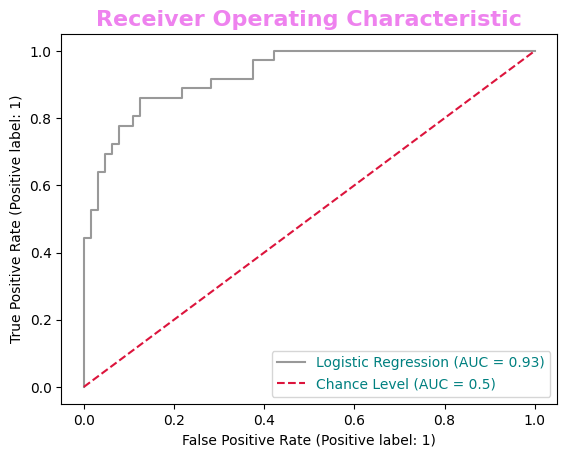

In [ ]:
ax = plt.gca()
RocCurveDisplay.from_estimator(log, X_test, y_test, color = 'grey', ax = ax,
                               alpha = 0.8, name = 'Logistic Regression')
ax.plot([0, 1], [0, 1], color = 'crimson', linestyle = '--',
         label = 'Chance Level (AUC = 0.5)')
plt.title('Receiver Operating Characteristic',
          fontdict = {'color' : 'violet', 'weight' : 'bold', 'size' : 16})
plt.legend(labelcolor = 'teal')
plt.show()

**Accuracy Score**

In [ ]:
pred_log = log.predict(X_test)

In [ ]:
accuracy_log = accuracy_score(y_test, pred_log)
print("Accuracy score of Logistic Regression is: ", accuracy_log)

Accuracy score of Logistic Regression is:  0.86


In [ ]:
cm = confusion_matrix(y_test, pred_log)

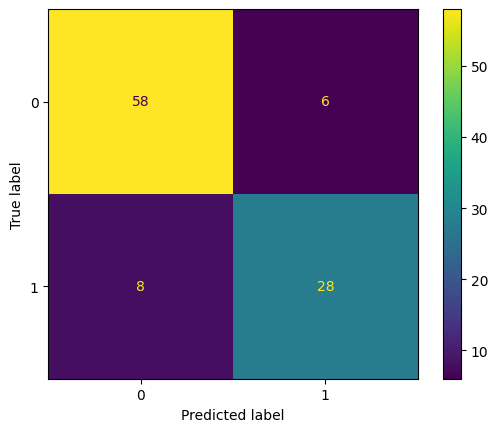

In [ ]:
matrix = ConfusionMatrixDisplay(cm).plot()

In [ ]:
print(classification_report(y_test, pred_log))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89        64
           1       0.82      0.78      0.80        36

    accuracy                           0.86       100
   macro avg       0.85      0.84      0.85       100
weighted avg       0.86      0.86      0.86       100



# 2. Random Forest Classifier

In [ ]:
rf = RandomForestClassifier()

In [ ]:
rf.fit(X_train, y_train)

RandomForestClassifier()

**ROC Curve**

In [ ]:
rf_pred_proba = rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, rf_pred_proba)
rf_roc_auc = auc(fpr, tpr)

roc_auc = roc_auc_score(y_test, rf_pred_proba)

print(f"ROC AUC Score: {rf_roc_auc:.3f}")
print(roc_auc)

ROC AUC Score: 1.000
1.0


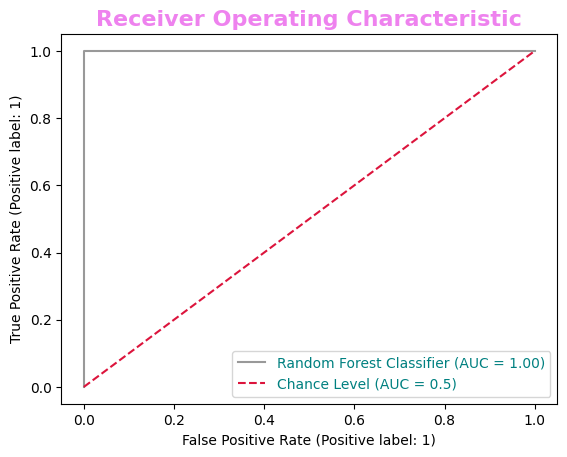

In [ ]:
ax = plt.gca()
RocCurveDisplay.from_estimator(rf, X_test, y_test, color = 'grey', ax = ax,
                               alpha = 0.8, name = 'Random Forest Classifier')
ax.plot([0, 1], [0, 1], color = 'crimson', linestyle = '--',
         label = 'Chance Level (AUC = 0.5)')
plt.title('Receiver Operating Characteristic',
          fontdict = {'color' : 'violet', 'weight' : 'bold', 'size' : 16})
plt.legend(labelcolor = 'teal')
plt.show()

**Accuracy Score**

In [ ]:
pred_rf = rf.predict(X_test)

In [ ]:
accuracy_rf = accuracy_score(y_test, pred_rf)
print("Accuracy score of Random Forest Classifier is: ", accuracy_rf)

Accuracy score of Random Forest Classifier is:  0.99


In [ ]:
cmrf = confusion_matrix(y_test, pred_rf)

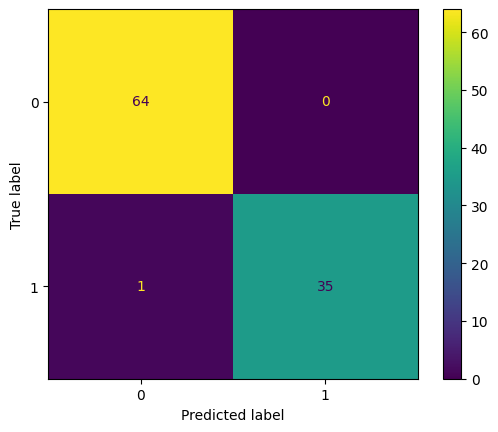

In [ ]:
display1 = ConfusionMatrixDisplay(cmrf).plot()

In [ ]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        64
           1       1.00      0.97      0.99        36

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



# 3. MultinomialNB

In [ ]:
mnb = MultinomialNB()

In [ ]:
mnb.fit(X_train, y_train)

MultinomialNB()

**ROC Curve**

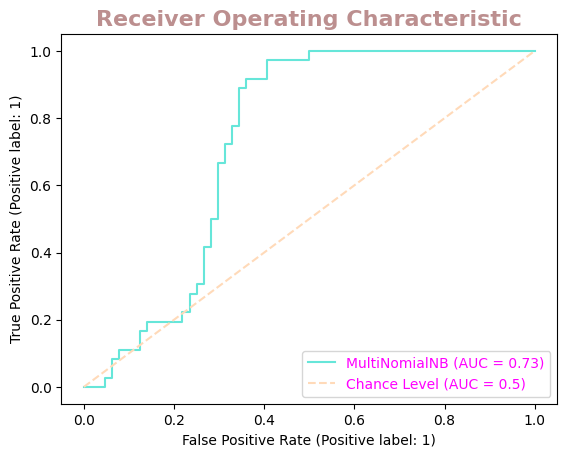

In [ ]:
ax = plt.gca()
RocCurveDisplay.from_estimator(mnb, X_test, y_test, color = 'turquoise', ax = ax,
                               alpha = 0.8, name = 'MultiNomialNB')
ax.plot([0, 1], [0, 1], color = 'peachpuff', linestyle = '--',
         label = 'Chance Level (AUC = 0.5)')
plt.title('Receiver Operating Characteristic',
          fontdict = {'color' : 'rosybrown', 'weight' : 'bold', 'size' : 16})
plt.legend(labelcolor = 'magenta')
plt.show()

**Accuracy Score**

In [ ]:
pred_mnb = mnb.predict(X_test)

In [ ]:
accuracy_mnb = accuracy_score(y_test, pred_mnb)
print("Accuracy score of MultinomialNB is: ", accuracy_mnb)

Accuracy score of MultinomialNB is:  0.59


In [ ]:
cmmnb = confusion_matrix(y_test, pred_mnb)

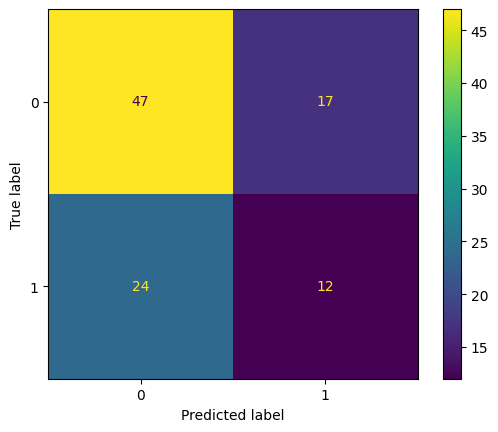

In [ ]:
display2 = ConfusionMatrixDisplay(cmmnb).plot()

In [ ]:
print(classification_report(y_test, pred_mnb))

              precision    recall  f1-score   support

           0       0.66      0.73      0.70        64
           1       0.41      0.33      0.37        36

    accuracy                           0.59       100
   macro avg       0.54      0.53      0.53       100
weighted avg       0.57      0.59      0.58       100



# 4. GaussianNB

In [ ]:
gnb = GaussianNB()

In [ ]:
gnb.fit(X_train, y_train)

GaussianNB()

**ROC Curve**

In [ ]:
gnb_pred_proba = gnb.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, gnb_pred_proba)
gnb_roc_auc = auc(fpr, tpr)

roc_auc = roc_auc_score(y_test, gnb_pred_proba)

print(f"ROC AUC Score: {gnb_roc_auc:.3f}")
print(roc_auc)

ROC AUC Score: 0.977
0.9769965277777778


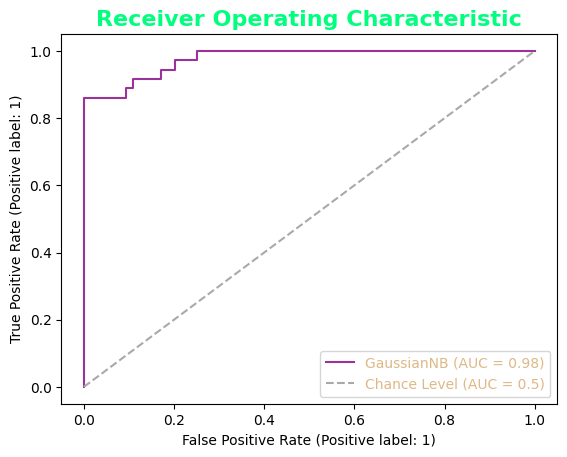

In [ ]:
ax = plt.gca()
RocCurveDisplay.from_estimator(gnb, X_test, y_test, color = 'purple', ax = ax,
                               alpha = 0.8, name = 'GaussianNB')
ax.plot([0, 1], [0, 1], color = 'darkgray', linestyle = '--',
         label = 'Chance Level (AUC = 0.5)')
plt.title('Receiver Operating Characteristic',
          fontdict = {'color' : 'springgreen', 'weight' : 'bold', 'size' : 16})
plt.legend(labelcolor = 'burlywood')
plt.show()

**Accuracy Score**

In [ ]:
pred_gnb = gnb.predict(X_test)

In [ ]:
accuracy_gnb = accuracy_score(y_test, pred_gnb)
print("Accuracy score of GaussianNB is: ", accuracy_gnb)

Accuracy score of GaussianNB is:  0.93


In [ ]:
cmgnb = confusion_matrix(y_test, pred_gnb)

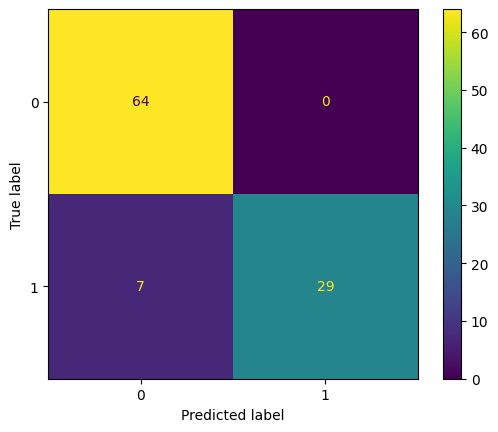

In [ ]:
display3 = ConfusionMatrixDisplay(cmgnb).plot()

In [ ]:
print(classification_report(y_test, pred_gnb))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95        64
           1       1.00      0.81      0.89        36

    accuracy                           0.93       100
   macro avg       0.95      0.90      0.92       100
weighted avg       0.94      0.93      0.93       100



#  5. Gradient Boosting Classifier

In [ ]:
gbc = GradientBoostingClassifier()

In [ ]:
gbc.fit(X_train, y_train)

GradientBoostingClassifier()

**ROC Curve**

In [ ]:
gbc_pred_proba = gbc.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, gbc_pred_proba)
gbc_roc_auc = auc(fpr, tpr)

roc_auc = roc_auc_score(y_test, gbc_pred_proba)

print(f"ROC AUC Score: {gbc_roc_auc:.3f}")
print(roc_auc)

ROC AUC Score: 0.982
0.982421875


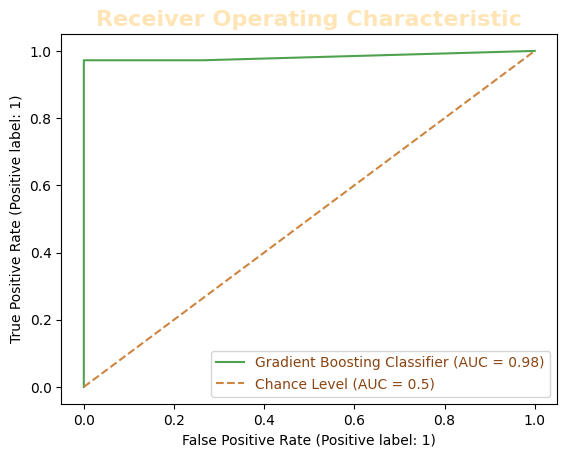

In [ ]:
ax = plt.gca()
RocCurveDisplay.from_estimator(gbc, X_test, y_test, color = 'forestgreen', ax = ax,
                               alpha = 0.8, name = 'Gradient Boosting Classifier')
ax.plot([0, 1], [0, 1], color = 'peru', linestyle = '--',
         label = 'Chance Level (AUC = 0.5)')
plt.title('Receiver Operating Characteristic',
          fontdict = {'color' : 'moccasin', 'weight' : 'bold', 'size' : 16})
plt.legend(labelcolor = 'saddlebrown')
plt.show()

**Accuracy Score**

In [ ]:
pred_gbc = gbc.predict(X_test)

In [ ]:
accuracy_gbc = accuracy_score(y_test, pred_gbc)
print("Accuracy score of Gradient Boosting Classifier is: ", accuracy_gbc)

Accuracy score of Gradient Boosting Classifier is:  0.99


In [ ]:
cmgbc = confusion_matrix(y_test, pred_gbc)

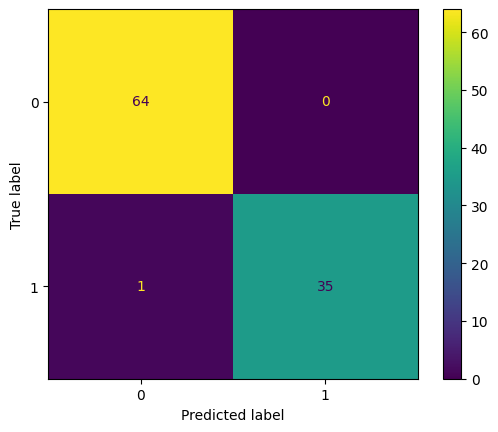

In [ ]:
display4 = ConfusionMatrixDisplay(cmgbc).plot()

In [ ]:
print(classification_report(y_test, pred_gbc))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        64
           1       1.00      0.97      0.99        36

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



# Metric Comparison

In [ ]:
comparison = pd.DataFrame()

comparison['Type'] = ['Logistic Regression', 'Random Forest', 'MultinomialNB',
                      'GaussianNB', 'Gradient Boosting']
comparison['Accuracy Score'] = [accuracy_log, accuracy_rf, accuracy_mnb, accuracy_gnb,
                                accuracy_gbc]
comparison['ROC AUC Score'] = [log_roc_auc, rf_roc_auc, '-', gnb_roc_auc,
                               gbc_roc_auc]
comparison

,Type,Accuracy Score,ROC AUC Score
0,Logistic Regression,0.86,0.930122
1,Random Forest,0.99,1.0
2,MultinomialNB,0.59,-
3,GaussianNB,0.93,0.976997
4,Gradient Boosting,0.99,0.982422


In [ ]:
# Graph of model comparison
fig = go.Figure()
fig.add_trace(go.Bar(x = comparison['Type'], y = comparison['Accuracy Score'],
              name = 'Accuracy Score', text = comparison['Accuracy Score'],
                    texttemplate = '%{text:.2f}'))
fig.add_trace(go.Bar(x = comparison['Type'],  y = comparison['ROC AUC Score'],
                     name = 'ROC AUC Score', text = comparison['ROC AUC Score'],
                     texttemplate = '%{text:.2f}'))
fig.update_traces(marker_line_color = 'darkslategrey', marker_line_width = 1.0)
                  #texttemplate = '%{text:.2f}', textposition = 'inside')
fig.update_xaxes(title = 'Models')
fig.update_yaxes(title = 'Scores')
fig.update_layout(title = {'text' : 'Metric Comparison', 'font_color' : 'purple', 'x' : 0.5,
                           'y' : 0.9, 'xanchor' : 'center', 'yanchor' : 'top'},
                  font_color = 'mediumaquamarine')
fig.show()

After comparing the model we find that Random Forest Classifier performs the best, with an accuracy score of 99% and ROC AUC score of 1.0. So, we will use Random Forest Classifier for Pass/Fail prediction.

# Predicting Exam Score using Random Forest Classifier

In [ ]:
input_test_data = (9.168098, 47.238152)
prediction = pred_rf[4]

In [ ]:
if prediction == 1:
    print('Pass')
else:
    print('Fail')

Fail


In [ ]:
X_test.head()

,Study Hours,Previous Exam Score
361,6.789594,67.197330
73,8.339153,77.325202
374,1.640698,41.523181
155,3.178497,47.654818
104,9.168098,47.238152


In [ ]:
y_test.head()

361    1
73     1
374    0
155    0
104    0
Name: Pass/Fail, dtype: int64

In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout, BatchNormalization, MaxPooling1D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd
import numpy as np

In [26]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/student/adjusted_student_performance.csv")

In [27]:
# Encode categorical features
label_encoders = {}
for col in ["Gender", "ParentalSupport"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Select features and target
X = df.drop(columns=["StudentID", "Name", "FinalGrade", "Pass/Fail"])
y = df["FinalGrade"]

In [28]:


# Normalize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [29]:






# Reshape for CNN input (1D input for Conv1D)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build CNN model
model = Sequential([
    Conv1D(64, kernel_size=3, activation="relu", input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Conv1D(128, kernel_size=3, activation="relu"),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(1, activation="linear")  # Predicting FinalGrade (continuous)
])




/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [31]:
# Build CNN model
model = Sequential([
    Conv1D(64, kernel_size=3, activation="relu", input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),  # First MaxPooling1D layer
    Conv1D(128, kernel_size=3, activation="relu"),
    BatchNormalization(),
    # Adjust or remove the second MaxPooling1D layer
    # Option 1: Reduce pool_size
    #MaxPooling1D(pool_size=1),
    # Option 2: Remove the second MaxPooling1D layer entirely
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(1, activation="linear")  # Predicting FinalGrade (continuous)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [32]:
# Compile model
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# Train model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=16)

# Save model
model.save("student_performance_cnn.h5")

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 4364.6328 - mae: 65.8948 - val_loss: 4469.0698 - val_mae: 66.7506
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3683.4858 - mae: 60.4370 - val_loss: 4398.1924 - val_mae: 66.2135
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2877.5610 - mae: 53.2129 - val_loss: 4268.8901 - val_mae: 65.2213
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2018.9606 - mae: 43.8208 - val_loss: 4051.0847 - val_mae: 63.5157
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1315.5785 - mae: 32.3828 - val_loss: 3737.8958 - val_mae: 60.9877
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 546.4119 - mae: 18.8342 - val_loss: 3357.4314 - val_mae: 57.8035
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 293.5659 - mae: 14.6301 - val_loss: 3000.0750 - val_mae: 54.7185
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 152.9733 - mae: 9.7060 - val_loss: 2770.2888 - val_mae: 52.5941
Epoch 9/50
7/7 ━━━━━

In [33]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=16, callbacks=[early_stopping])


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 57.9054 - mae: 5.8307 - val_loss: 112.1303 - val_mae: 9.3206
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 59.0192 - mae: 5.7471 - val_loss: 132.8739 - val_mae: 9.9388
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 50.5724 - mae: 5.7022 - val_loss: 112.2739 - val_mae: 9.1278
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 69.6114 - mae: 6.6103 - val_loss: 111.7661 - val_mae: 9.0386
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 53.3044 - mae: 6.0018 - val_loss: 128.8553 - val_mae: 9.4790
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 71.1396 - mae: 6.8423 - val_loss: 113.5635 - val_mae: 9.1306
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 50.7736 - mae: 5.8623 - val_loss: 84.1208 - val_mae: 7.4967
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 46.6704 - mae: 5.5214 - val_loss: 96.1327 - val_mae: 8.1082
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step 

In [38]:
df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek_x,PreviousGrade_x,ExtracurricularActivities,ParentalSupport,FinalGrade,StudyHoursPerWeek_y,PreviousGrade_y,Pass/Fail
0,3.0,Alex,0,78.0,10.0,65.0,0.0,0,68.0,8.0,59.0,0.0
1,3.0,Alex,0,78.0,10.0,65.0,0.0,0,68.0,10.0,65.0,1.0
2,3.0,Alex,0,78.0,10.0,65.0,0.0,0,68.0,6.0,56.0,0.0
3,3.0,Alex,0,78.0,10.0,65.0,0.0,0,68.0,7.0,61.0,1.0
4,3.0,Alex,0,78.0,10.0,65.0,0.0,0,68.0,9.0,64.0,1.0


In [50]:
!pip uninstall Keras

Found existing installation: keras 3.8.0
Uninstalling keras-3.8.0:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/keras-3.8.0.dist-info/*
    /usr/local/lib/python3.11/dist-packages/keras/*
Proceed (Y/n)? Y
  Successfully uninstalled keras-3.8.0


In [51]:
pip install tensorflow==2.12.0

INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 MB 8.9 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninsta

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout, BatchNormalization, MaxPooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/student/adjusted_student_performance.csv")

# Encode categorical features
label_encoders = {}
for col in ["Gender", "ParentalSupport"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Select features and target
X = df.drop(columns=["StudentID", "Name", "FinalGrade", "Pass/Fail"])
y = df["FinalGrade"]

# Normalize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Normalize target variable (FinalGrade) between 0 and 1
y_scaler = MinMaxScaler()
y = y_scaler.fit_transform(y.values.reshape(-1, 1))

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Reshape for CNN input (1D input for Conv1D)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build Optimized CNN model
model = Sequential([
    Conv1D(64, kernel_size=3, activation="relu", input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=1),  # FIX: Reduced pool_size to avoid shrinking too much

    Conv1D(128, kernel_size=3, activation="relu", kernel_regularizer=l2(0.01)),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation="relu", kernel_regularizer=l2(0.01)),
    Dropout(0.4),

    Dense(64, activation="relu", kernel_regularizer=l2(0.01)),
    Dropout(0.4),

    Dense(1, activation="sigmoid")  # Predicting FinalGrade (normalized between 0-1)
])

# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss="mse", metrics=["mae"])

# Add Early Stopping & Learning Rate Reduction
callbacks = [
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=0.0001)
]

# Train model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=16, callbacks=callbacks)

# Save model
model.save("student.h5")


Epoch 1/100
7/7 [==============================] - 2s 49ms/step - loss: 3.7721 - mae: 0.1941 - val_loss: 3.7186 - val_mae: 0.2795 - lr: 5.0000e-04
Epoch 2/100
7/7 [==============================] - 0s 12ms/step - loss: 3.5449 - mae: 0.0801 - val_loss: 3.5215 - val_mae: 0.2641 - lr: 5.0000e-04
Epoch 3/100
7/7 [==============================] - 0s 10ms/step - loss: 3.3508 - mae: 0.0615 - val_loss: 3.3201 - val_mae: 0.2577 - lr: 5.0000e-04
Epoch 4/100
7/7 [==============================] - 0s 12ms/step - loss: 3.1527 - mae: 0.0583 - val_loss: 3.1216 - val_mae: 0.2556 - lr: 5.0000e-04
Epoch 5/100
7/7 [==============================] - 0s 10ms/step - loss: 2.9526 - mae: 0.0446 - val_loss: 2.9283 - val_mae: 0.2529 - lr: 5.0000e-04
Epoch 6/100
7/7 [==============================] - 0s 10ms/step - loss: 2.7608 - mae: 0.0459 - val_loss: 2.7416 - val_mae: 0.2517 - lr: 5.0000e-04
Epoch 7/100
7/7 [==============================] - 0s 12ms/step - loss: 2.5752 - mae: 0.0396 - val_loss: 2.5631 - val_

In [3]:
from tensorflow.keras.models import load_model
import tensorflow as tf
import numpy as np

# Load the model with the correct loss function
model = load_model("//content/student.h5", compile=False)

# Recompile with the correct loss function
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss="mse",
              metrics=["mae"])

# Test Prediction
sample_input = np.array(X_test[:1])  # Take one sample from test data
prediction = model.predict(sample_input)
print("Predicted Final Grade:", prediction)


1/1 [==============================] - 0s 263ms/step
Predicted Final Grade: [[0.03798427]]


In [4]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the trained model
model = load_model("/content/student.h5", compile=False)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss="mse", metrics=["mae"])

# Sample data from your dataset to set up preprocessing (adjust if needed)
df = pd.read_csv("/content/drive/MyDrive/student/adjusted_student_performance.csv")

# Define feature columns
feature_columns = ["Gender", "AttendanceRate", "StudyHoursPerWeek_x", "PreviousGrade_x",
                   "ExtracurricularActivities", "ParentalSupport", "StudyHoursPerWeek_y", "PreviousGrade_y"]

# Convert categorical values into numerical (Gender & Parental Support)
gender_encoder = LabelEncoder()
df["Gender"] = gender_encoder.fit_transform(df["Gender"])  # Converts 'Male' -> 1, 'Female' -> 0

parental_support_map = {"Low": 0, "Medium": 1, "High": 2}
df["ParentalSupport"] = df["ParentalSupport"].map(parental_support_map)

# Preprocessing (like in training)
scaler = StandardScaler()
X = df[feature_columns]
X_scaled = scaler.fit_transform(X)

# Function to predict final grade
def predict_grade():
    print("Enter the following details to predict the student's final grade:")

    gender_input = input("Gender (Male/Female): ")
    attendance_rate = float(input("Attendance Rate (0-100): "))
    study_hours_x = float(input("Study Hours Per Week (Dataset 1): "))
    previous_grade_x = float(input("Previous Grade (Dataset 1, 0-100): "))
    extracurricular = int(input("Extracurricular Activities (0-3): "))
    parental_support_input = input("Parental Support (Low/Medium/High): ")
    study_hours_y = float(input("Study Hours Per Week (Dataset 2): "))
    previous_grade_y = float(input("Previous Grade (Dataset 2, 0-100): "))

    # Convert Gender to numerical
    gender_encoded = 1 if gender_input.lower() == "male" else 0

    # Convert parental support to numerical
    parental_support = parental_support_map.get(parental_support_input, 1)  # Default to Medium if unknown

    # Prepare input data
    user_input = np.array([[gender_encoded, attendance_rate, study_hours_x, previous_grade_x,
                            extracurricular, parental_support, study_hours_y, previous_grade_y]])

    # Scale input data
    user_input_scaled = scaler.transform(user_input)
    user_input_scaled = user_input_scaled.reshape((user_input_scaled.shape[0], user_input_scaled.shape[1], 1))

    # Predict grade
    predicted_grade = model.predict(user_input_scaled)

    # Display result
    print(f"\nPredicted Final Grade: {predicted_grade[0][0] * 100:.2f}/100")

# Run prediction
predict_grade()


Enter the following details to predict the student's final grade:
Gender (Male/Female): Malr
Attendance Rate (0-100): 45
Study Hours Per Week (Dataset 1): 5
Previous Grade (Dataset 1, 0-100): 45
Extracurricular Activities (0-3): 1
Parental Support (Low/Medium/High): High
Study Hours Per Week (Dataset 2): 5
Previous Grade (Dataset 2, 0-100): 85
1/1 [==============================] - 0s 126ms/step

Predicted Final Grade: 0.00/100


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [5]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the trained model
model = load_model("/content/student.h5", compile=False)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss="mse", metrics=["mae"])

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/student/adjusted_student_performance.csv")

# Define feature columns
feature_columns = ["Gender", "AttendanceRate", "StudyHoursPerWeek_x", "PreviousGrade_x",
                   "ExtracurricularActivities", "ParentalSupport", "StudyHoursPerWeek_y", "PreviousGrade_y"]

# Convert categorical values into numerical (Gender & Parental Support)
gender_encoder = LabelEncoder()
df["Gender"] = gender_encoder.fit_transform(df["Gender"])  # Converts 'Male' -> 1, 'Female' -> 0

parental_support_map = {"Low": 0, "Medium": 1, "High": 2}
df["ParentalSupport"] = df["ParentalSupport"].map(parental_support_map)

# Preprocessing (like in training)
scaler = StandardScaler()
X = df[feature_columns]
X_scaled = scaler.fit_transform(X)

# Function to predict final grade and provide recommendations
def predict_grade():
    print("Enter the following details to predict the student's final grade:")

    gender_input = input("Gender (Male/Female): ")
    attendance_rate = float(input("Attendance Rate (0-100): "))
    study_hours_x = float(input("Study Hours Per Week (Dataset 1): "))
    previous_grade_x = float(input("Previous Grade (Dataset 1, 0-100): "))
    extracurricular = int(input("Extracurricular Activities (0-3): "))
    parental_support_input = input("Parental Support (Low/Medium/High): ")
    study_hours_y = float(input("Study Hours Per Week (Dataset 2): "))
    previous_grade_y = float(input("Previous Grade (Dataset 2, 0-100): "))

    # Convert Gender to numerical
    gender_encoded = 1 if gender_input.lower() == "male" else 0

    # Convert parental support to numerical
    parental_support = parental_support_map.get(parental_support_input, 1)  # Default to Medium if unknown

    # Prepare input data
    user_input = np.array([[gender_encoded, attendance_rate, study_hours_x, previous_grade_x,
                            extracurricular, parental_support, study_hours_y, previous_grade_y]])

    # Scale input data
    user_input_scaled = scaler.transform(user_input)
    user_input_scaled = user_input_scaled.reshape((user_input_scaled.shape[0], user_input_scaled.shape[1], 1))

    # Predict grade
    predicted_grade = model.predict(user_input_scaled)[0][0] * 100  # Convert to percentage

    # Determine performance category
    if predicted_grade >= 90:
        performance = "Excellent 🌟"
        recommendation = "Keep up the great work! Consider challenging yourself with advanced topics."
    elif predicted_grade >= 75:
        performance = "Good ✅"
        recommendation = "You’re doing well! Maintain consistency and focus on areas for minor improvements."
    elif predicted_grade >= 50:
        performance = "Average ⚠️"
        recommendation = "You need to improve. Spend more time on weak subjects and increase study hours."
    else:
        performance = "Needs Improvement ❌"
        recommendation = "Urgent action needed! Seek tutoring, revise regularly, and manage time better."

    # Display result
    print(f"\n📊 **Predicted Final Grade:** {predicted_grade:.2f}/100")
    print(f"📌 **Performance Level:** {performance}")
    print(f"📝 **Recommendation:** {recommendation}")

# Run prediction
predict_grade()


Enter the following details to predict the student's final grade:
Gender (Male/Female): Female
Attendance Rate (0-100): 85
Study Hours Per Week (Dataset 1): 9
Previous Grade (Dataset 1, 0-100): 78
Extracurricular Activities (0-3): 1
Parental Support (Low/Medium/High): Low
Study Hours Per Week (Dataset 2): 5
Previous Grade (Dataset 2, 0-100): 98


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 [==============================] - 0s 170ms/step

📊 **Predicted Final Grade:** 91.30/100
📌 **Performance Level:** Excellent 🌟
📝 **Recommendation:** Keep up the great work! Consider challenging yourself with advanced topics.
